# Social Network Analysis with R

### Objective
Implement a complete Social Network Analysis workflow using R by:

- Preparing network relationship data
- Representing entities as nodes and relationships as edges
- Constructing a social network
- Visualizing the network
- Calculating important network measures
- Identifying influential nodes
- Detecting communities
- Interpreting the results

This uses the `igraph` package for network analysis.

## 1. Installing Required Packages

In [1]:
install.packages("igraph", repos = "https://cloud.r-project.org")
install.packages("dplyr", repos = "https://cloud.r-project.org")
install.packages("ggplot2", repos = "https://cloud.r-project.org")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



## 2. Loading Libraries

In [2]:
library(igraph)
library(dplyr)
library(ggplot2)


Attaching package: ‘igraph’


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union



Attaching package: ‘dplyr’


The following objects are masked from ‘package:igraph’:

    as_data_frame, groups, union


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




## 3. Preparing the Social Network Dataset

Each row represents a relationship between two people.

- `from` → first person
- `to` → second person

For this experiment, the network is treated as **undirected**, meaning that a connection between two people is mutual.

In [3]:
edges <- data.frame(
  from = c(
    "Alice", "Alice", "Alice",
    "Bob", "Bob",
    "Charlie", "Charlie",
    "David", "David",
    "Eve", "Eve",
    "Frank",
    "George"
  ),

  to = c(
    "Bob", "Charlie", "David",
    "Charlie", "Eve",
    "David", "Eve",
    "Eve", "Frank",
    "Frank", "George",
    "George",
    "Alice"
  )
)

print(edges)

      from      to
1    Alice     Bob
2    Alice Charlie
3    Alice   David
4      Bob Charlie
5      Bob     Eve
6  Charlie   David
7  Charlie     Eve
8    David     Eve
9    David   Frank
10     Eve   Frank
11     Eve  George
12   Frank  George
13  George   Alice


4. Constructing the Social Network

In [4]:
g <- graph_from_data_frame(
  edges,
  directed = FALSE
)

print(g)

IGRAPH 24232fe UN-- 7 13 -- 
+ attr: name (v/c)
+ edges from 24232fe (vertex names):
 [1] Alice  --Bob     Alice  --Charlie Alice  --David   Bob    --Charlie
 [5] Bob    --Eve     Charlie--David   Charlie--Eve     David  --Eve    
 [9] David  --Frank   Eve    --Frank   Eve    --George  Frank  --George 
[13] Alice  --George 


## 5. Displaying Nodes and Edges

In [5]:
cat("Number of nodes:", vcount(g), "\n")
cat("Number of edges:", ecount(g), "\n")

cat("\nNodes:\n")
print(V(g)$name)

cat("\nEdges:\n")
print(as_edgelist(g))

Number of nodes: 7 
Number of edges: 13 

Nodes:
[1] "Alice"   "Bob"     "Charlie" "David"   "Eve"     "Frank"   "George" 

Edges:
      [,1]      [,2]     
 [1,] "Alice"   "Bob"    
 [2,] "Alice"   "Charlie"
 [3,] "Alice"   "David"  
 [4,] "Bob"     "Charlie"
 [5,] "Bob"     "Eve"    
 [6,] "Charlie" "David"  
 [7,] "Charlie" "Eve"    
 [8,] "David"   "Eve"    
 [9,] "David"   "Frank"  
[10,] "Eve"     "Frank"  
[11,] "Eve"     "George" 
[12,] "Frank"   "George" 
[13,] "Alice"   "George" 


## 6. Basic Network Visualization

The graph visually represents people as nodes and their relationships as edges.

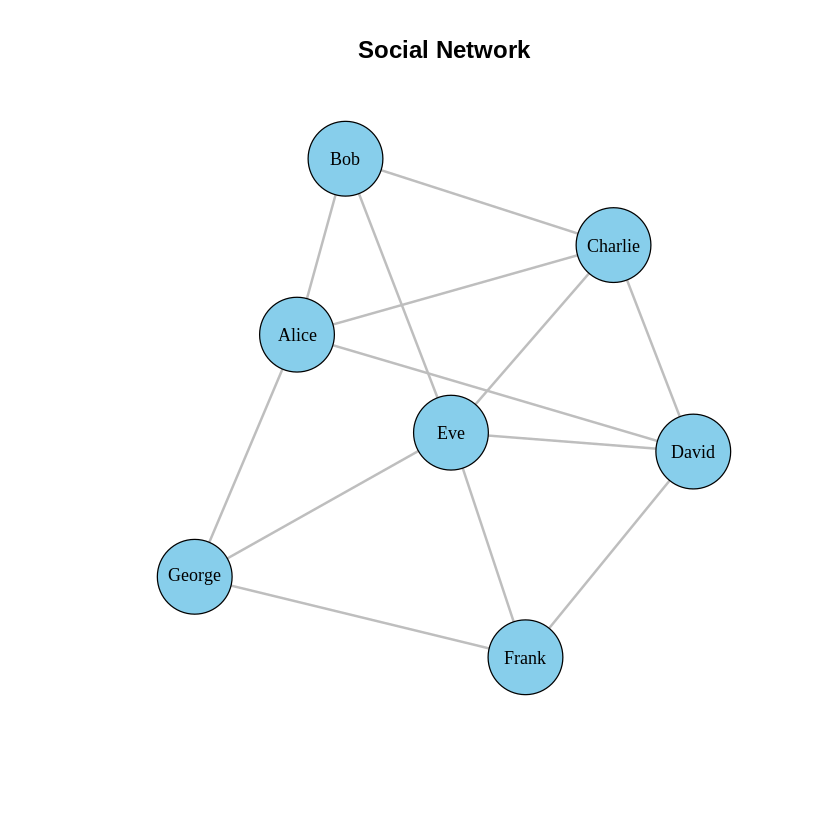

In [6]:
set.seed(123)

plot(
  g,
  layout = layout_with_fr(g),
  vertex.size = 30,
  vertex.color = "skyblue",
  vertex.label.color = "black",
  vertex.label.cex = 0.9,
  edge.color = "gray",
  edge.width = 2,
  main = "Social Network"
)

## 7. Degree Centrality

Degree centrality measures the number of direct connections associated with each node.

A node with a high degree is highly connected within the network.

In [7]:
degree_values <- degree(g)

degree_results <- data.frame(
  Node = names(degree_values),
  Degree = as.numeric(degree_values)
)

degree_results <- degree_results %>%
  arrange(desc(Degree))

print(degree_results)

     Node Degree
1     Eve      5
2   Alice      4
3 Charlie      4
4   David      4
5     Bob      3
6   Frank      3
7  George      3


### Most Highly Connected Node

In [9]:
max_degree <- max(degree_values)

most_connected <- names(
  degree_values[degree_values == max_degree]
)

cat("Highest Degree:", max_degree, "\n")
cat("Most Connected Node:", paste(most_connected, collapse = ", "), "\n")

Highest Degree: 5 
Most Connected Node: Eve 


## 8. Betweenness Centrality

Betweenness centrality identifies nodes that frequently lie on shortest paths between other nodes.

Such nodes often act as bridges between different parts of the network.

In [10]:
betweenness_values <- betweenness(g, normalized = TRUE)

betweenness_results <- data.frame(
  Node = names(betweenness_values),
  Betweenness = as.numeric(betweenness_values)
) %>%
  arrange(desc(Betweenness))

print(betweenness_results)

     Node Betweenness
1     Eve  0.21111111
2   Alice  0.11111111
3   David  0.08333333
4  George  0.05000000
5 Charlie  0.03888889
6   Frank  0.02222222
7     Bob  0.01666667


## 9. Closeness Centrality

Closeness centrality measures how close a node is to all other nodes in the network based on shortest paths.

In [11]:
closeness_values <- closeness(g, normalized = TRUE)

closeness_results <- data.frame(
  Node = names(closeness_values),
  Closeness = as.numeric(closeness_values)
) %>%
  arrange(desc(Closeness))

print(closeness_results)

     Node Closeness
1     Eve 0.8571429
2   Alice 0.7500000
3 Charlie 0.7500000
4   David 0.7500000
5     Bob 0.6666667
6   Frank 0.6666667
7  George 0.6666667


## 10. PageRank

PageRank measures node importance by considering both the number and importance of neighboring nodes.

In [12]:
pagerank_values <- page_rank(g)$vector

pagerank_results <- data.frame(
  Node = names(pagerank_values),
  PageRank = as.numeric(pagerank_values)
) %>%
  arrange(desc(PageRank))

print(pagerank_results)

     Node  PageRank
1     Eve 0.1869378
2   Alice 0.1531291
3   David 0.1517294
4 Charlie 0.1514013
5  George 0.1195567
6   Frank 0.1193249
7     Bob 0.1179207


## 11. Combined Network Measures

In [13]:
network_measures <- data.frame(
  Node = V(g)$name,
  Degree = degree(g),
  Betweenness = betweenness(g, normalized = TRUE),
  Closeness = closeness(g, normalized = TRUE),
  PageRank = page_rank(g)$vector
)

network_measures <- network_measures %>%
  arrange(desc(Degree))

print(network_measures)

           Node Degree Betweenness Closeness  PageRank
Eve         Eve      5  0.21111111 0.8571429 0.1869378
Alice     Alice      4  0.11111111 0.7500000 0.1531291
Charlie Charlie      4  0.03888889 0.7500000 0.1514013
David     David      4  0.08333333 0.7500000 0.1517294
Bob         Bob      3  0.01666667 0.6666667 0.1179207
Frank     Frank      3  0.02222222 0.6666667 0.1193249
George   George      3  0.05000000 0.6666667 0.1195567


## 12. Visualize Influential Nodes

Node size is proportional to degree.

Nodes with degree greater than or equal to the network's average degree are highlighted.

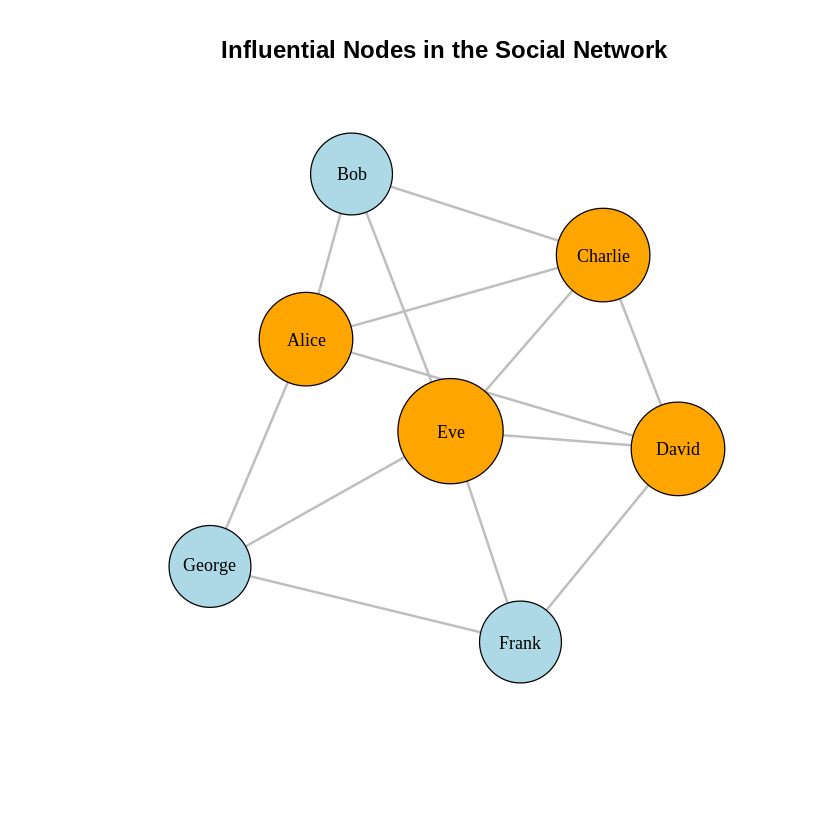

In [14]:
degree_values <- degree(g)

V(g)$size <- 20 + (degree_values * 5)

V(g)$color <- ifelse(
  degree_values >= mean(degree_values),
  "orange",
  "lightblue"
)

set.seed(123)

plot(
  g,
  layout = layout_with_fr(g),
  vertex.label.color = "black",
  vertex.label.cex = 0.9,
  edge.color = "gray",
  edge.width = 2,
  main = "Influential Nodes in the Social Network"
)

## 13. Network-Level Measures

Important properties of the complete network are calculated below.

In [15]:
cat("Number of Nodes:", vcount(g), "\n")
cat("Number of Edges:", ecount(g), "\n")
cat("Network Density:", round(edge_density(g), 3), "\n")
cat("Average Degree:", round(mean(degree(g)), 3), "\n")
cat("Number of Connected Components:", components(g)$no, "\n")
cat("Network Diameter:", diameter(g), "\n")
cat("Average Path Length:", round(mean_distance(g), 3), "\n")

Number of Nodes: 7 
Number of Edges: 13 
Network Density: 0.619 
Average Degree: 3.714 
Number of Connected Components: 1 
Network Diameter: 2 
Average Path Length: 1.381 


## 14. Community Detection

The Louvain algorithm identifies groups of nodes that are more densely connected internally than with the rest of the network.

In [16]:
communities <- cluster_louvain(g)

print(communities)

cat("\nCommunity membership:\n")
print(membership(communities))

cat("\nNumber of communities:",
    length(unique(membership(communities))), "\n")

IGRAPH clustering multi level, groups: 2, mod: 0.1
+ groups:
  $`1`
  [1] "Alice"   "Bob"     "Charlie" "David"  
  
  $`2`
  [1] "Eve"    "Frank"  "George"
  

Community membership:
  Alice     Bob Charlie   David     Eve   Frank  George 
      1       1       1       1       2       2       2 

Number of communities: 2 


### Community Visualization

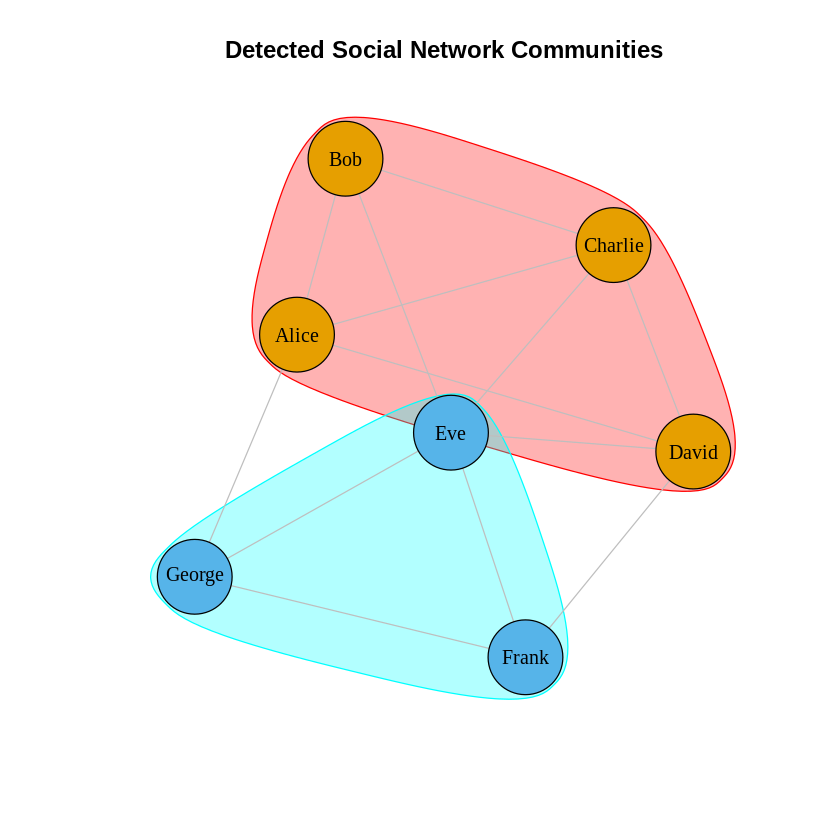

In [17]:
set.seed(123)

plot(
  communities,
  g,
  layout = layout_with_fr(g),
  vertex.size = 30,
  vertex.label.color = "black",
  edge.color = "gray",
  main = "Detected Social Network Communities"
)

## 15. Degree Distribution

The following plot shows how node connections are distributed in the social network.

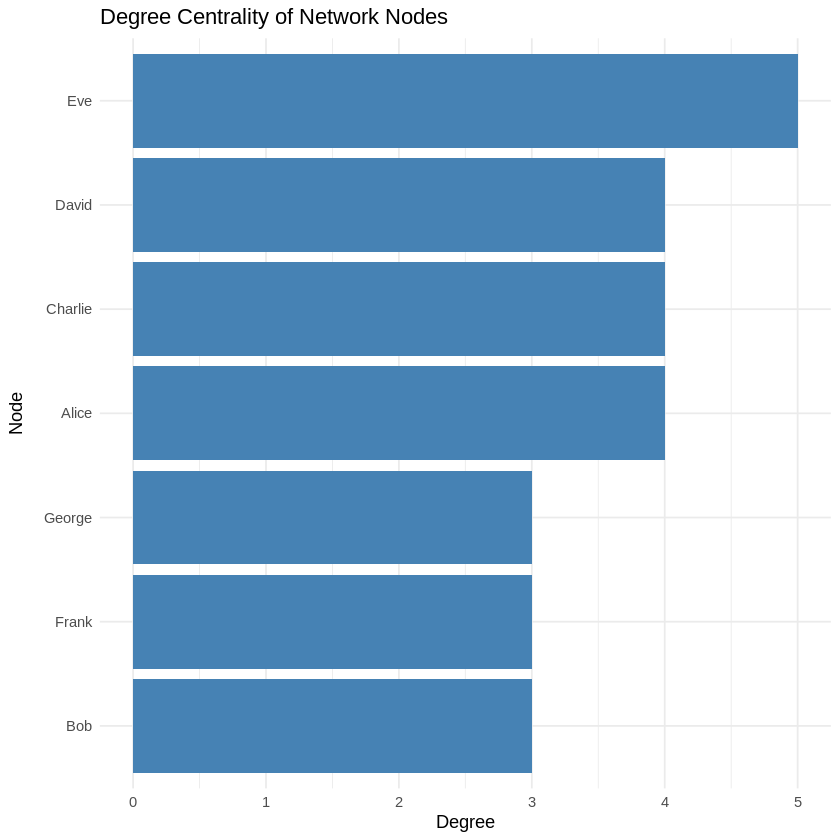

In [18]:
degree_data <- data.frame(
  Node = V(g)$name,
  Degree = degree(g)
)

ggplot(
  degree_data,
  aes(x = reorder(Node, Degree), y = Degree)
) +
  geom_col(fill = "steelblue") +
  coord_flip() +
  labs(
    title = "Degree Centrality of Network Nodes",
    x = "Node",
    y = "Degree"
  ) +
  theme_minimal()

## 16. Automatically Identify Important Nodes

The following cell identifies the node with the highest value for each centrality measure.

In [19]:
top_degree_node <- names(which.max(degree(g)))
top_betweenness_node <- names(which.max(betweenness(g)))
top_closeness_node <- names(which.max(closeness(g)))
top_pagerank_node <- names(which.max(page_rank(g)$vector))

cat("Highest Degree Centrality :", top_degree_node, "\n")
cat("Highest Betweenness       :", top_betweenness_node, "\n")
cat("Highest Closeness         :", top_closeness_node, "\n")
cat("Highest PageRank          :", top_pagerank_node, "\n")

Highest Degree Centrality : Eve 
Highest Betweenness       : Eve 
Highest Closeness         : Eve 
Highest PageRank          : Eve 




After executing the notebook, interpret the output using the following points:

1. **Degree Centrality**  
   The node having the highest degree has the largest number of direct connections and can be considered one of the most socially active entities.

2. **Betweenness Centrality**  
   A node with high betweenness acts as a bridge connecting different parts of the social network.

3. **Closeness Centrality**  
   A node with high closeness can reach other nodes using relatively short paths.

4. **PageRank**  
   A high PageRank value indicates that a node is connected to other important nodes and can therefore be regarded as influential.

5. **Network Density**  
   Density indicates how strongly interconnected the network is compared with the maximum possible number of relationships.

6. **Community Detection**  
   Communities represent clusters of people who are relatively more closely connected to one another.

The exact influential nodes and values should be taken from the outputs generated after execution.

## Conclusion

In this experiment, Social Network Analysis was implemented using R and the `igraph` package. The social relationships were represented using nodes and edges, and the resulting graph was analyzed using degree, betweenness, closeness, PageRank, density, path-based measures, and community detection.

The visualizations and calculated measures help identify important or influential entities and provide insight into the overall structure of the network.
